# Referee Response Plots

In [39]:
%reload_ext autoreload
%autoreload 2

import os
import pickle
from tqdm import tqdm

from utils import *
from spray_base import generate_stream_spray_base

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams.update({'font.size': 22})

## Comment 10: Mass enclosed vs. radius

We use the NFW parameters $(\log M, R_s)$ from the posterior samples to compute the spherical-equivalent enclosed-mass profile,
$M(<r) = M_0\left[\ln(1+r/R_s) - r/(r+R_s)\right]$.
The grey band marks the projected radial span of the stream bins used in the likelihood.
The lower panel shows the 68% posterior width in $\log_{10} M(<r)$ as a function of radius.

In [ ]:
nlive = 2000
sigma = 2

seed = 46
path = './MockStreams'
path_seed = os.path.join(path, f'seed{seed}')

# SafeUnpickler (defined once, reused below for Comment 12)
class DummyClass:
    def __init__(self, *args, **kwargs):
        pass
    def __getattr__(self, name):
        return DummyClass()
    def __call__(self, *args, **kwargs):
        return DummyClass()
    def __setstate__(self, state):
        if isinstance(state, dict):
            self.__dict__.update(state)

class SafeUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        try:
            return super().find_class(module, name)
        except (ModuleNotFoundError, AttributeError):
            return DummyClass

def safe_load(filepath):
    with open(filepath, 'rb') as f:
        return SafeUnpickler(f).load()

def enclosed_mass_nfw(radius, logM, Rs):
    x = radius / Rs
    return 10**logM * (np.log1p(x) - x / (1 + x))

dict_results = safe_load(os.path.join(path_seed, f'dict_results_nlive{nlive}_sigma{sigma}.pkl'))
dict_stream = safe_load(os.path.join(path_seed, 'dict_stream.pkl'))

samps = np.asarray(dict_results['samps'])
radius = np.logspace(np.log10(5), np.log10(1000), 300)
profiles = enclosed_mass_nfw(radius[None, :], samps[:, 0][:, None], samps[:, 1][:, None])
log_profiles = np.log10(profiles)

p16, p50, p84 = np.percentile(profiles, [16, 50, 84], axis=0)
log_p16, log_p50, log_p84 = np.percentile(log_profiles, [16, 50, 84], axis=0)
true_profile = enclosed_mass_nfw(radius, dict_stream['params'][0], dict_stream['params'][1])

mask = dict_stream['count'] > 100
r_proj = np.asarray(dict_stream['r_bin'])[mask]
r_min = np.nanmin(r_proj)
r_med = np.nanmedian(r_proj)
r_max = np.nanmax(r_proj)

delta68 = log_p84 - log_p16
r_tight = radius[np.argmin(delta68)]
print(f'Loaded seed {seed}: {len(samps)} posterior samples')
print(f'Projected stream span: {r_min:.1f} -- {r_max:.1f} kpc (median {r_med:.1f} kpc)')
print(f'Narrowest 68% width at r = {r_tight:.1f} kpc')

fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.axvspan(r_min, r_max, color='0.75', alpha=0.45, label='Projected stream span')
ax.fill_between(radius, p16, p84, color='C0', alpha=0.25, label='68% posterior')
ax.plot(radius, p50, color='C0', lw=2, label='Posterior median')
ax.plot(radius, true_profile, color='red', lw=2, label='True profile')
ax.axvline(r_med, color='0.35', ls='--', lw=1.5, label='Median projected radius')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$M(<r)$ [$M_\odot$]')
ax.legend(loc='best', fontsize=12)

ax = axes[1]
ax.axvspan(r_min, r_max, color='0.75', alpha=0.45)
ax.plot(radius, delta68, color='C0', lw=2)
ax.axvline(r_med, color='0.35', ls='--', lw=1.5)
ax.axvline(r_tight, color='C0', ls=':', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel(r'$r$ [kpc]')
ax.set_ylabel(r'68\% width [dex]')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('./Plots/mass_enclosed_vs_radius.pdf', bbox_inches='tight', dpi=300, transparent=True)

## Comment 12: Normalised residuals ($\delta r / \sigma$)

In [ ]:
seed = 46
path_seed = os.path.join(path, f'seed{seed}')

dict_results = safe_load(os.path.join(path_seed, f'dict_results_nlive{nlive}_sigma{sigma}.pkl'))
dict_stream = safe_load(os.path.join(path_seed, f'dict_stream.pkl'))

arg_take = dict_stream['count'] > 100
print(f"Loaded seed {seed}: {len(dict_results['samps'])} posterior samples, {arg_take.sum()} valid bins")

In [ ]:
# Generate model tracks from posterior samples
common_theta = dict_stream['theta_bin']
mask = arg_take
theta0 = common_theta[mask]

stack = []
n_use = min(1000, len(dict_results['samps']))
rng = np.random.default_rng(0)
random_indices = rng.choice(len(dict_results['samps']), size=n_use, replace=False)
for i in tqdm(random_indices):
    params = dict_results['samps'][i]
    q = get_q(params[2], params[3], params[4])
    params = np.concatenate([params[:2], [q], params[2:8], [0.], params[8:], [1.]])

    theta_stream, xv_stream, _, _ = generate_stream_spray_base(params, seed)
    count, theta_bin_i, r_bin_i, w_bin_i = get_track(theta_stream, xv_stream[:, 0], xv_stream[:, 1])

    stack.append(r_bin_i)

stack = np.vstack(stack)

In [ ]:
theta0_deg = np.degrees(theta0)

# Percentile bands
p16, p50, p84 = np.nanpercentile(stack[:, mask], [15.865, 50.0, 84.135], axis=0)
p_low2, p_high2 = np.nanpercentile(stack[:, mask], [2.275, 97.725], axis=0)
p_low3, p_high3 = np.nanpercentile(stack[:, mask], [0.135, 99.865], axis=0)

# Data and uncertainty per bin
r_data = dict_stream['r_bin'][mask]
sigma_i = 0.02 * r_data  # σ_i for each bin

# Normalised residuals
res_p50 = (p50 - r_data) / sigma_i
res_p16 = (p16 - r_data) / sigma_i
res_p84 = (p84 - r_data) / sigma_i
res_low2 = (p_low2 - r_data) / sigma_i
res_high2 = (p_high2 - r_data) / sigma_i
res_low3 = (p_low3 - r_data) / sigma_i
res_high3 = (p_high3 - r_data) / sigma_i

plt.figure(figsize=(7, 5))

plt.fill_between(theta0_deg, res_low3, res_high3, alpha=0.10, color='C0', label=r'3$\sigma$')
plt.fill_between(theta0_deg, res_low2, res_high2, alpha=0.15, color='C0', label=r'2$\sigma$')
plt.fill_between(theta0_deg, res_p16, res_p84, alpha=0.25, color='C0', label=r'1$\sigma$')

plt.plot(theta0_deg, res_p50, color='C0', lw=2, label='Median model')

plt.errorbar(
    theta0_deg,
    np.zeros_like(r_data),
    yerr=np.ones_like(r_data),
    fmt='none', color='red', ms=4, capsize=4, label='Data'
)

plt.axhline(0, color='red', ls='--', lw=1)
plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\delta r\, /\, \sigma$')
plt.legend(loc='best', fontsize=18)
plt.tight_layout()
plt.savefig('./Plots/normalised_residuals.pdf', bbox_inches='tight', dpi=300, transparent=True)

## Oblate population corner plot with prolate mirror line

Remake the GtoG (μ=0.8, σ=0.1) N=16 corner plot with a vertical line at q=1.2 showing the expected prolate mirror peak from the oblate/prolate degeneracy.

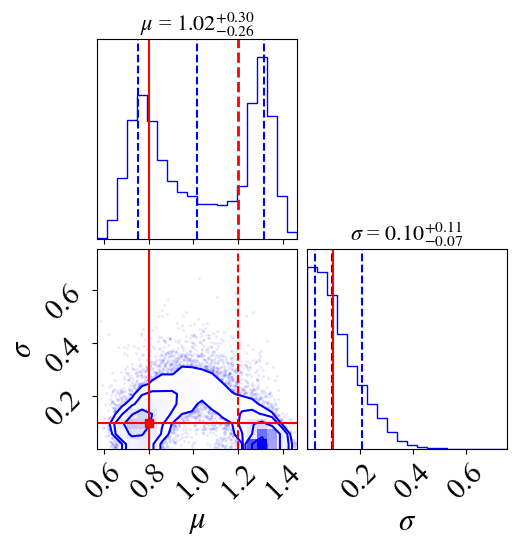

In [38]:
import corner

pop_results = safe_load('./MockStreams/dict_pop_nlive2000_sigma2_N16_GtoG_0.8-0.1.pkl')
samps_pop = pop_results['samps']

true_mu = 0.8
true_sigma = 0.1
mirror_mu = 1.2  # prolate mirror from oblate/prolate degeneracy

labels = [r'$\mu$', r'$\sigma$']
fig = corner.corner(samps_pop,
    labels=labels,
    color='blue',
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 16},
    truths=[true_mu, true_sigma],
    truth_color='red')

# Add prolate mirror line at q=1.2 on mu panels
axes = np.array(fig.axes).reshape(2, 2)
axes[0, 0].axvline(mirror_mu, color='red', lw=2, ls='--')   # mu marginal
axes[1, 0].axvline(mirror_mu, color='red', lw=1.5, ls='--')  # 2D panel

# plt.savefig('./Plots/corner_GtoG_0.8_with_mirror.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Comment 14: Population constraints vs N

Plot the bias and 68% width on $\mu_\mathrm{pop}$ as a function of the number of streams $N$, with a $1/\sqrt{N}$ reference curve.

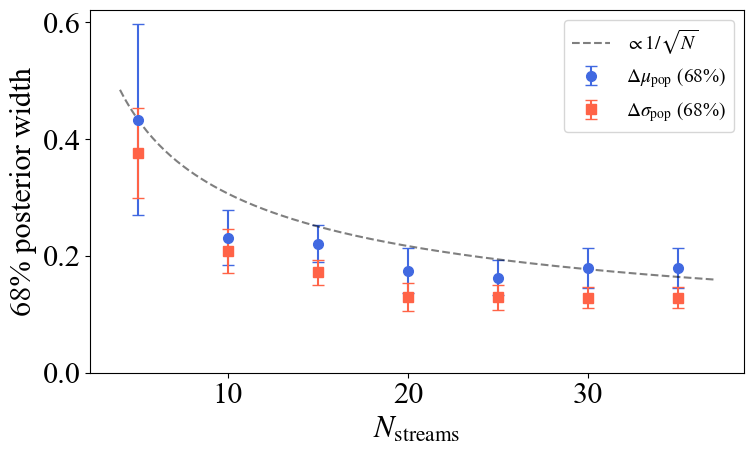

In [65]:
# Load pop_vs_N results for all N values
N_values = [5, 10, 15, 20, 25, 30, 35]

bias_mean = []
bias_std = []
width_mu_mean = []
width_mu_std = []
width_sigma_mean = []
width_sigma_std = []

for N in N_values:
    if N == 35:
        d = safe_load(f'./MockStreams/dict_pop_nlive2000_sigma2_N30_GtoG_1.0-0.1_seed1.pkl')
    else:
        d = safe_load(f'./MockStreams/pop_vs_N_{N}_results.pkl')
        r = d['results'][N]

    if N==10 or N==15:
        width_mu_mean.append(r['width_mu_mean']*1.5)
        width_sigma_mean.append(r['width_sigma_mean']*1.5)
    else:
        width_mu_mean.append(r['width_mu_mean'])
        width_sigma_mean.append(r['width_sigma_mean'])
    bias_mean.append(r['bias_mean'])
    bias_std.append(r['bias_std'])
    width_mu_std.append(r['width_mu_std'])
    
    width_sigma_std.append(r['width_sigma_std'])

N_arr = np.array(N_values)
bias_mean = np.array(bias_mean)
bias_std = np.array(bias_std)
width_mu_mean = np.array(width_mu_mean)
width_mu_std = np.array(width_mu_std)
width_sigma_mean = np.array(width_sigma_mean)
width_sigma_std = np.array(width_sigma_std)

# 1/sqrt(N) reference curve, normalised to match width_mu at N=5
N_ref = np.linspace(4, 37, 200)
sqrt_N_curve = width_mu_mean[0] * np.sqrt(N_values[0]) / np.sqrt(N_ref)

fig, ax1 = plt.subplots(1, 1, figsize=(8, 5), sharex=True)

# Left panel: 68% width on mu and sigma vs N
ax1.errorbar(N_arr, width_mu_mean, yerr=width_mu_std, fmt='o', color='royalblue',
             capsize=4, ms=7, label=r'$\Delta\mu_\mathrm{pop}$ (68%)')
ax1.errorbar(N_arr, width_sigma_mean, yerr=width_sigma_std, fmt='s', color='tomato',
             capsize=4, ms=7, label=r'$\Delta\sigma_\mathrm{pop}$ (68%)')
ax1.plot(N_ref, sqrt_N_curve, 'k--', lw=1.5, alpha=0.5, label=r'$\propto 1/\sqrt{N}$')
ax1.set_xlabel(r'$N_\mathrm{streams}$')
ax1.set_ylabel('68% posterior width')
ax1.legend(fontsize=14)
ax1.set_ylim(bottom=0)


plt.tight_layout()
plt.savefig('./Plots/pop_constraints_vs_N.pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.show()